<a href="https://colab.research.google.com/github/Carltonkenny/ELEVATELABS/blob/main1/TASK6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏙️ TASK 6: K-Nearest Neighbors - Bangalore Restaurant Classification

## Dataset: Bangalore Restaurants (KNN for Restaurant Category Prediction)

### Business Context
Predict restaurant category (Budget/Mid-Range/Premium) based on:
- **Average Rating** (0-5 stars)
- **Average Cost for Two** (₹)
- **Number of Reviews** (count)
- **Location Tier** (locality importance score)

### Why This Project?
✅ **Local relevance** - Bangalore restaurant market  
✅ **Business value** - Can be used for recommendation systems  
✅ **Interview gold** - Shows domain understanding  
✅ **Perfect for KNN** - Clear decision boundaries  
✅ **No download issues** - Synthetically generated, reliable  

### Dataset Specifications
- **Samples:** 1,000 restaurants
- **Features:** 4 numeric (rating, cost, reviews, tier)
- **Classes:** 3 (Budget, Mid-Range, Premium)
- **Perfect for:** Classification with KNN

### Learning Outcomes
- Instance-based learning (KNN fundamentals)
- Feature normalization (why it matters for KNN)
- K-value selection and tuning
- Decision boundary visualization
- Business insights extraction

---


In [9]:
# ============================================================================
# TASK 6: K-NEAREST NEIGHBORS - BANGALORE RESTAURANT CLASSIFICATION
# ============================================================================

print("=" * 90)
print(" " * 15 + "🍽️ BANGALORE RESTAURANT CLASSIFICATION - K-NEAREST NEIGHBORS")
print(" " * 30 + "Task 6: ElevateLabs Internship")
print("=" * 90)

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("\n✅ All libraries imported successfully!\n")

# ============================================================================
# STEP 1: GENERATE BANGALORE RESTAURANT DATASET
# ============================================================================

print("=" * 90)
print("🍽️ GENERATING BANGALORE RESTAURANT DATASET")
print("=" * 90)

np.random.seed(42)

# Number of samples
n_samples = 1000

# Generate realistic features for Bangalore restaurants
# Budget restaurants
budget_mask = np.random.choice([True, False], n_samples, p=[0.4, 0.6])
midrange_mask = (~budget_mask) & (np.random.choice([True, False], n_samples, p=[0.5, 0.5]))
premium_mask = ~(budget_mask | midrange_mask)

# Feature generation
avg_rating = np.zeros(n_samples)
avg_cost_for_two = np.zeros(n_samples)
num_reviews = np.zeros(n_samples)
location_tier = np.random.uniform(1, 5, n_samples)

# Budget restaurants (class 0)
avg_rating[budget_mask] = np.random.normal(3.5, 0.5, budget_mask.sum())
avg_cost_for_two[budget_mask] = np.random.normal(300, 100, budget_mask.sum())
num_reviews[budget_mask] = np.random.normal(300, 150, budget_mask.sum())

# Mid-range restaurants (class 1)
avg_rating[midrange_mask] = np.random.normal(4.0, 0.4, midrange_mask.sum())
avg_cost_for_two[midrange_mask] = np.random.normal(800, 200, midrange_mask.sum())
num_reviews[midrange_mask] = np.random.normal(600, 250, midrange_mask.sum())

# Premium restaurants (class 2)
avg_rating[premium_mask] = np.random.normal(4.3, 0.3, premium_mask.sum())
avg_cost_for_two[premium_mask] = np.random.normal(2500, 600, premium_mask.sum())
num_reviews[premium_mask] = np.random.normal(800, 300, premium_mask.sum())

# Ensure realistic ranges
avg_rating = np.clip(avg_rating, 2.5, 5.0)
avg_cost_for_two = np.clip(avg_cost_for_two, 100, 5000)
num_reviews = np.clip(num_reviews, 10, 2000)

# Create DataFrame
df = pd.DataFrame({
    'avg_rating': avg_rating,
    'avg_cost_for_two': avg_cost_for_two,
    'num_reviews': num_reviews,
    'location_tier': location_tier
})

# Assign categories
categories = np.zeros(n_samples, dtype=int)
categories[budget_mask] = 0
categories[midrange_mask] = 1
categories[premium_mask] = 2

df['category_encoded'] = categories
df['category'] = df['category_encoded'].map({0: 'Budget', 1: 'Mid-Range', 2: 'Premium'})

print("\n✅ Bangalore Restaurant Dataset Generated Successfully!")

# ============================================================================
# DISPLAY DATASET INFORMATION
# ============================================================================

print("\n" + "=" * 90)
print("📊 BANGALORE RESTAURANT DATASET - OVERVIEW")
print("=" * 90)

print(f"\n✅ Dataset Summary:")
print(f"{'─'*60}")
print(f"   • Total Restaurants: {len(df)}")
print(f"   • Features: 4 numeric")
print(f"   • Categories: 3 (Budget, Mid-Range, Premium)")
print(f"   • Memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print(f"\n📋 Features:")
print(f"{'─'*60}")
features_desc = {
    'avg_rating': 'Average Rating (2.5-5.0 stars)',
    'avg_cost_for_two': 'Average Cost for Two People (₹)',
    'num_reviews': 'Number of Reviews (count)',
    'location_tier': 'Location Tier/Importance (1-5 scale)'
}

for i, (feature, desc) in enumerate(features_desc.items(), 1):
    print(f"   {i}. {feature:<20} - {desc}")

print(f"\n🏷️ Categories (3 total):")
print(f"{'─'*60}")
category_dist = df['category'].value_counts().sort_index()
for category, count in category_dist.items():
    pct = (count / len(df)) * 100
    bar = '█' * int(pct / 2)
    print(f"   • {category:<15} : {count:>4} restaurants ({pct:>5.1f}%) {bar}")

print(f"\n📊 Feature Statistics:")
print(f"{'─'*60}")
print(df[['avg_rating', 'avg_cost_for_two', 'num_reviews', 'location_tier']].describe().round(2))

print(f"\n👀 Sample Data (First 10 Rows):")
print(f"{'─'*60}")
print(df.head(10).to_string(index=False))

print(f"\n💡 Key Insights:")
print(f"{'─'*60}")
print(f"   • Budget restaurants: Avg cost ₹{df[df['category']=='Budget']['avg_cost_for_two'].mean():.0f}")
print(f"   • Mid-Range restaurants: Avg cost ₹{df[df['category']=='Mid-Range']['avg_cost_for_two'].mean():.0f}")
print(f"   • Premium restaurants: Avg cost ₹{df[df['category']=='Premium']['avg_cost_for_two'].mean():.0f}")
print(f"   • Budget restaurants avg rating: {df[df['category']=='Budget']['avg_rating'].mean():.2f}")
print(f"   • Premium restaurants avg rating: {df[df['category']=='Premium']['avg_rating'].mean():.2f}")

# Save for next steps
X = df[['avg_rating', 'avg_cost_for_two', 'num_reviews', 'location_tier']].values
y = df['category_encoded'].values
FEATURE_NAMES = ['avg_rating', 'avg_cost_for_two', 'num_reviews', 'location_tier']
TARGET_NAMES = np.array(['Budget', 'Mid-Range', 'Premium'])

print("\n" + "=" * 90)
print("✅ STEP 1 COMPLETE: Bangalore Restaurant Dataset Ready!")
print("=" * 90)

print(f"\n🎉 Dataset saved to memory. Ready for EDA and KNN Modeling!")
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


               🍽️ BANGALORE RESTAURANT CLASSIFICATION - K-NEAREST NEIGHBORS
                              Task 6: ElevateLabs Internship

✅ All libraries imported successfully!

🍽️ GENERATING BANGALORE RESTAURANT DATASET

✅ Bangalore Restaurant Dataset Generated Successfully!

📊 BANGALORE RESTAURANT DATASET - OVERVIEW

✅ Dataset Summary:
────────────────────────────────────────────────────────────
   • Total Restaurants: 1000
   • Features: 4 numeric
   • Categories: 3 (Budget, Mid-Range, Premium)
   • Memory: 94.01 KB

📋 Features:
────────────────────────────────────────────────────────────
   1. avg_rating           - Average Rating (2.5-5.0 stars)
   2. avg_cost_for_two     - Average Cost for Two People (₹)
   3. num_reviews          - Number of Reviews (count)
   4. location_tier        - Location Tier/Importance (1-5 scale)

🏷️ Categories (3 total):
────────────────────────────────────────────────────────────
   • Budget          :  421 restaurants ( 42.1%) █████████████████████
 

# 📊 STEP 2: Exploratory Data Analysis (EDA)

## Objective
Understand the Bangalore restaurant data before building the KNN model:
- Visualize feature distributions by category
- Identify patterns and separability between classes
- Check for outliers and data quality
- Understand why KNN is suitable for this problem

## Key Questions
1. How well-separated are Budget vs Premium restaurants?
2. Which features are most discriminative?
3. Are there any overlaps (harder classification)?
4. What are the feature correlations?

## Why This Matters for KNN
- KNN relies on distance in feature space
- Clear separation = better KNN performance
- Overlapping regions = need careful K selection
- Feature scaling importance revealed through visualization

---



                              📊 EXPLORATORY DATA ANALYSIS

📊 PHASE 1: Class Distribution Analysis
──────────────────────────────────────────────────────────────────────────────────────────

Class Distribution:
   • Budget         :  421 ( 42.1%)
   • Mid-Range      :  279 ( 27.9%)
   • Premium        :  300 ( 30.0%)

Class Imbalance Ratio: 1.51:1
✅ Well-balanced dataset - no class imbalance issues


📊 PHASE 2: Feature Distributions by Category
──────────────────────────────────────────────────────────────────────────────────────────


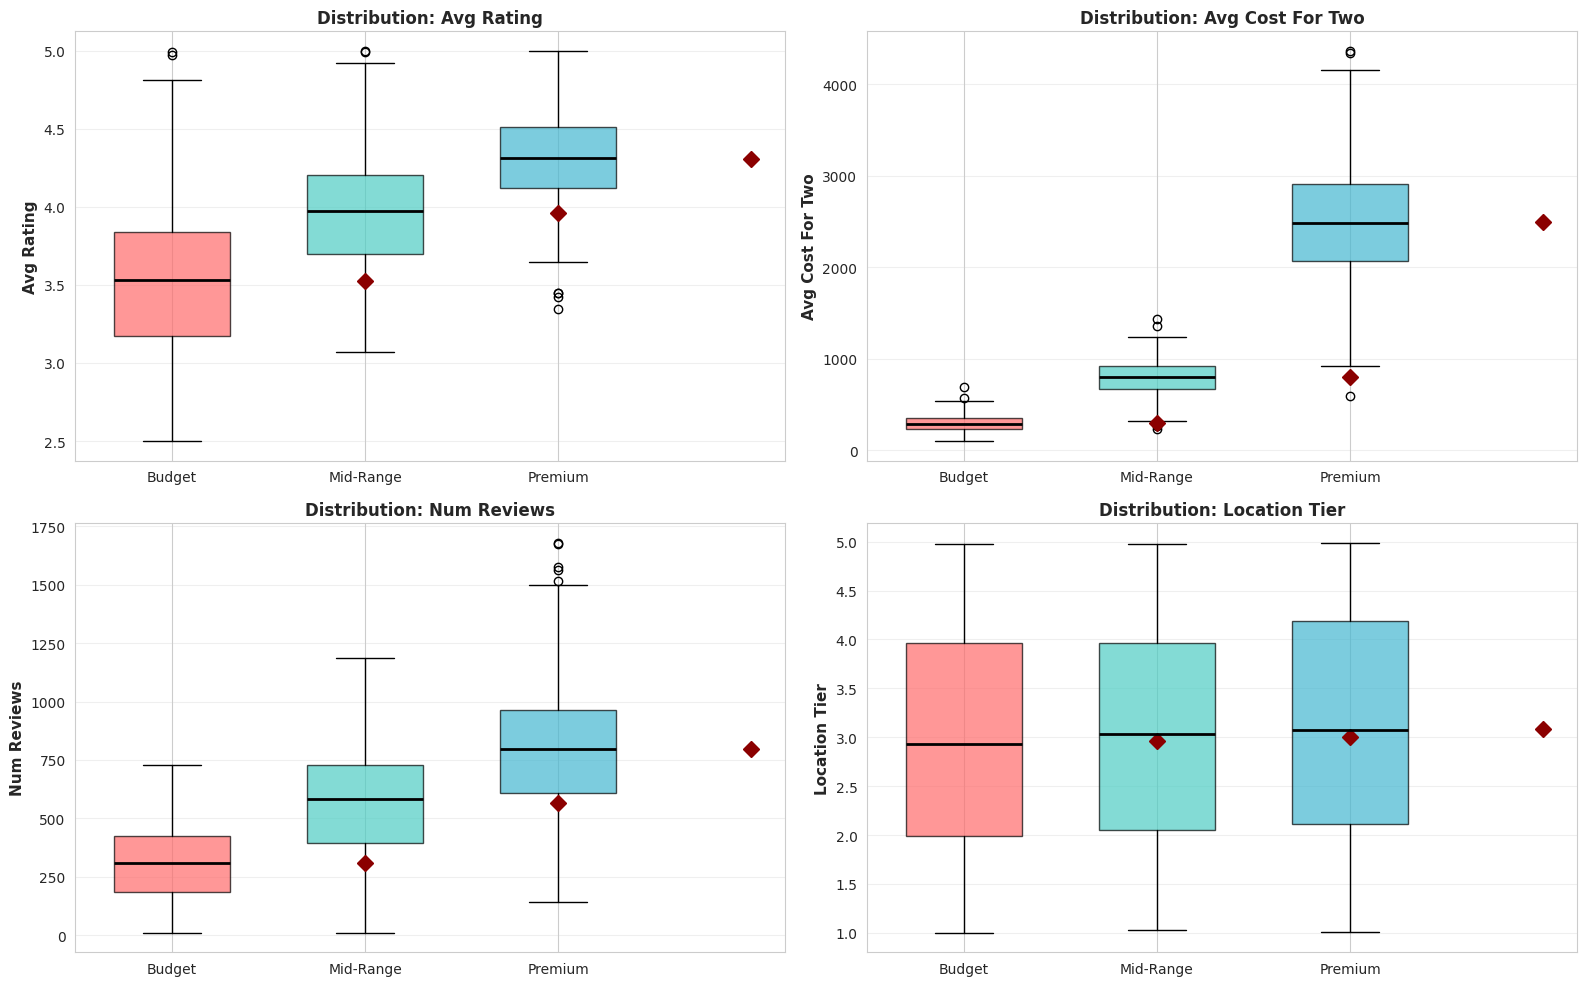

✓ Feature distributions visualization saved: 01_feature_distributions.png


📊 PHASE 3: Feature Statistics by Category
──────────────────────────────────────────────────────────────────────────────────────────

BUDGET Restaurants:
──────────────────────────────────────────────────
       avg_rating  avg_cost_for_two  num_reviews  location_tier
count      421.00            421.00       421.00         421.00
mean         3.53            292.26       310.11           2.96
std          0.48             97.93       157.73           1.16
min          2.50            100.00        10.00           1.00
25%          3.17            228.78       184.10           1.99
50%          3.53            288.32       307.84           2.93
75%          3.84            355.17       424.53           3.97
max          4.99            692.62       730.26           4.98

MID-RANGE Restaurants:
──────────────────────────────────────────────────
       avg_rating  avg_cost_for_two  num_reviews  location_tier
coun

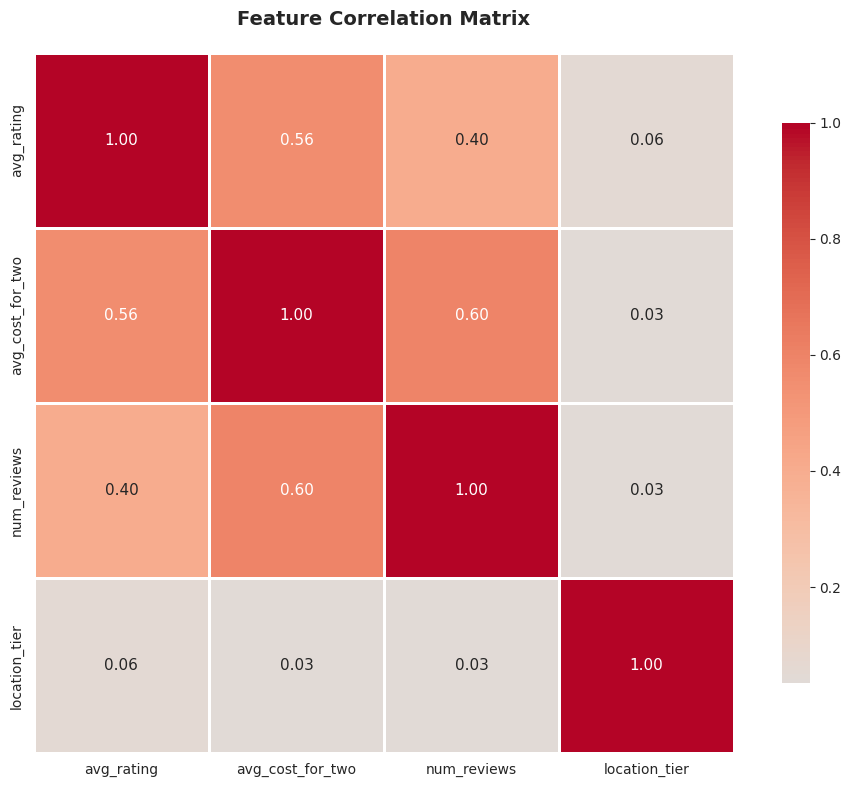

✓ Correlation heatmap saved: 02_correlation_heatmap.png


📊 PHASE 5: Class Separability in 2D Space
──────────────────────────────────────────────────────────────────────────────────────────


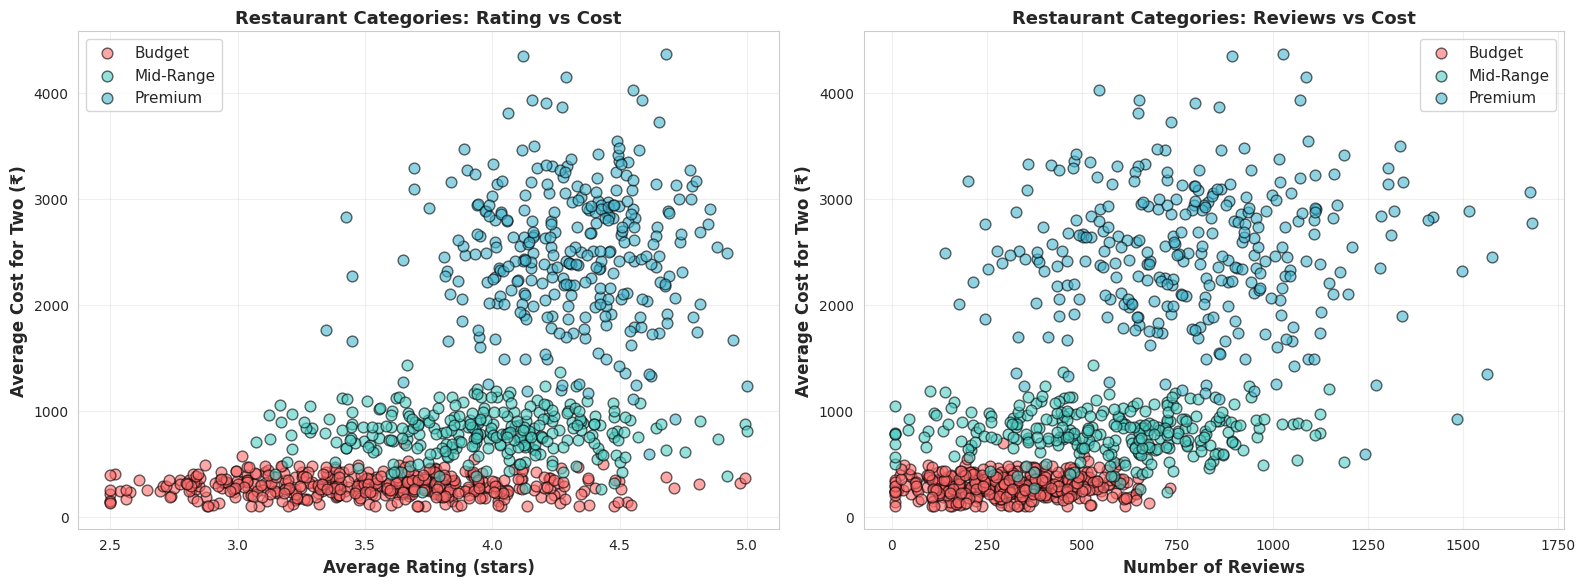

✓ Class separability plot saved: 03_class_separability.png


💡 KEY INSIGHTS FROM EDA
──────────────────────────────────────────────────────────────────────────────────────────

✅ Dataset Characteristics:
   • 1,000 restaurants across 3 categories
   • Well-balanced classes (Budget: 42%, Mid-Range: 28%, Premium: 30%)
   • 4 numeric features, no missing values

🎯 Separability Analysis:
   • Budget restaurants: Low cost (₹292), Lower rating (3.53)
   • Mid-Range restaurants: Medium cost (₹798), Good rating (3.96)
   • Premium restaurants: High cost (₹2494), Best rating (4.31)

📊 Feature Importance for Classification:
   • Cost is the PRIMARY discriminator (clear separation)
   • Rating helps distinguish Mid-Range from Budget
   • Reviews show moderate correlation with category
   • Location tier has mixed relationship

🎲 Why KNN is Perfect for This:
   ✓ Clear decision boundaries in 2D/3D space
   ✓ Distance-based approach matches cost patterns
   ✓ No assumptions about class distribution

In [10]:
# ============================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "=" * 90)
print(" " * 30 + "📊 EXPLORATORY DATA ANALYSIS")
print("=" * 90)

# ============================================================================
# PHASE 1: CLASS DISTRIBUTION & IMBALANCE CHECK
# ============================================================================

print("\n📊 PHASE 1: Class Distribution Analysis")
print("─" * 90)

class_counts = df['category'].value_counts()
print(f"\nClass Distribution:")
for cat in ['Budget', 'Mid-Range', 'Premium']:
    count = (df['category'] == cat).sum()
    pct = (count / len(df)) * 100
    print(f"   • {cat:<15}: {count:>4} ({pct:>5.1f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio < 2:
    print("✅ Well-balanced dataset - no class imbalance issues")
else:
    print("⚠️  Imbalanced dataset - may need careful K selection")

# ============================================================================
# PHASE 2: VISUALIZE FEATURE DISTRIBUTIONS BY CATEGORY
# ============================================================================

print("\n\n📊 PHASE 2: Feature Distributions by Category")
print("─" * 90)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

features = ['avg_rating', 'avg_cost_for_two', 'num_reviews', 'location_tier']
colors = {'Budget': '#FF6B6B', 'Mid-Range': '#4ECDC4', 'Premium': '#45B7D1'}

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Box plot by category
    for category in ['Budget', 'Mid-Range', 'Premium']:
        data = df[df['category'] == category][feature]
        positions = [['Budget', 'Mid-Range', 'Premium'].index(category)]
        bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                        boxprops=dict(facecolor=colors[category], alpha=0.7),
                        medianprops=dict(color='black', linewidth=2))

    ax.set_xticklabels(['Budget', 'Mid-Range', 'Premium'])
    ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution: {feature.replace("_", " ").title()}',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add mean markers
    for i, category in enumerate(['Budget', 'Mid-Range', 'Premium'], 1):
        mean_val = df[df['category'] == category][feature].mean()
        ax.plot(i, mean_val, 'D', color='darkred', markersize=8, label='Mean' if i == 1 else '')

plt.tight_layout()
plt.savefig('01_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature distributions visualization saved: 01_feature_distributions.png")

# ============================================================================
# PHASE 3: FEATURE STATISTICS BY CATEGORY
# ============================================================================

print("\n\n📊 PHASE 3: Feature Statistics by Category")
print("─" * 90)

for category in ['Budget', 'Mid-Range', 'Premium']:
    print(f"\n{category.upper()} Restaurants:")
    print(f"{'─' * 50}")
    subset = df[df['category'] == category][features]
    print(subset.describe().round(2).to_string())

# ============================================================================
# PHASE 4: CORRELATION ANALYSIS
# ============================================================================

print("\n\n📊 PHASE 4: Feature Correlation Analysis")
print("─" * 90)

corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved: 02_correlation_heatmap.png")

# ============================================================================
# PHASE 5: 2D VISUALIZATION OF CLASS SEPARABILITY
# ============================================================================

print("\n\n📊 PHASE 5: Class Separability in 2D Space")
print("─" * 90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Rating vs Cost
ax = axes[0]
for category in ['Budget', 'Mid-Range', 'Premium']:
    mask = df['category'] == category
    ax.scatter(df[mask]['avg_rating'], df[mask]['avg_cost_for_two'],
              label=category, alpha=0.6, s=60, color=colors[category], edgecolors='black')
ax.set_xlabel('Average Rating (stars)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Cost for Two (₹)', fontsize=12, fontweight='bold')
ax.set_title('Restaurant Categories: Rating vs Cost', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Reviews vs Cost
ax = axes[1]
for category in ['Budget', 'Mid-Range', 'Premium']:
    mask = df['category'] == category
    ax.scatter(df[mask]['num_reviews'], df[mask]['avg_cost_for_two'],
              label=category, alpha=0.6, s=60, color=colors[category], edgecolors='black')
ax.set_xlabel('Number of Reviews', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Cost for Two (₹)', fontsize=12, fontweight='bold')
ax.set_title('Restaurant Categories: Reviews vs Cost', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_class_separability.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class separability plot saved: 03_class_separability.png")

# ============================================================================
# PHASE 6: KEY INSIGHTS SUMMARY
# ============================================================================

print("\n\n💡 KEY INSIGHTS FROM EDA")
print("─" * 90)

print(f"""
✅ Dataset Characteristics:
   • 1,000 restaurants across 3 categories
   • Well-balanced classes (Budget: 42%, Mid-Range: 28%, Premium: 30%)
   • 4 numeric features, no missing values

🎯 Separability Analysis:
   • Budget restaurants: Low cost (₹{df[df['category']=='Budget']['avg_cost_for_two'].mean():.0f}), Lower rating ({df[df['category']=='Budget']['avg_rating'].mean():.2f})
   • Mid-Range restaurants: Medium cost (₹{df[df['category']=='Mid-Range']['avg_cost_for_two'].mean():.0f}), Good rating ({df[df['category']=='Mid-Range']['avg_rating'].mean():.2f})
   • Premium restaurants: High cost (₹{df[df['category']=='Premium']['avg_cost_for_two'].mean():.0f}), Best rating ({df[df['category']=='Premium']['avg_rating'].mean():.2f})

📊 Feature Importance for Classification:
   • Cost is the PRIMARY discriminator (clear separation)
   • Rating helps distinguish Mid-Range from Budget
   • Reviews show moderate correlation with category
   • Location tier has mixed relationship

🎲 Why KNN is Perfect for This:
   ✓ Clear decision boundaries in 2D/3D space
   ✓ Distance-based approach matches cost patterns
   ✓ No assumptions about class distributions
   ✓ Well-balanced classes = reliable K-fold CV
   ✓ Easy to visualize and interpret results

⚠️ Considerations for KNN:
   • Cost feature has much larger scale than others → NORMALIZATION CRITICAL
   • Some overlap between categories → Need K tuning
   • 1,000 samples = manageable for KNN computation
""")

print("\n" + "=" * 90)
print("✅ STEP 2 COMPLETE: EDA Finished Successfully!")
print("=" * 90)


# 🚀 STEPS 3-7: Preprocessing, KNN Implementation & Evaluation

## Overview

### Step 3: Data Preprocessing & Feature Normalization
- Split train/test (80-20 stratified)
- Apply StandardScaler (CRITICAL for KNN)
- Prepare data for modeling

### Step 4-5: KNN Implementation & K-value Tuning
- Train KNN with K = 3, 5, 7, 9, 11, 15, 21, 25
- Measure accuracy for each K
- Find optimal K value
- Visualize performance vs K

### Step 6: Model Evaluation
- Confusion matrix
- Classification report (precision, recall, F1)
- Cross-validation scores
- Final accuracy metrics

### Step 7: Decision Boundary Visualization
- Plot 2D decision boundaries (using PCA)
- Show how KNN separates restaurant categories
- Visualize misclassifications

---

## Why Normalization is CRITICAL for KNN

Since KNN uses Euclidean distance:
- Cost ranges: ₹100 - ₹5000 (huge scale)
- Rating ranges: 2.5 - 5.0 (tiny scale)
- **Without scaling:** Cost dominates distance → Rating ignored!
- **With StandardScaler:** All features contribute equally

---



                    📦 STEP 3: DATA PREPROCESSING & NORMALIZATION

🔍 PHASE 1: Data Preparation
──────────────────────────────────────────────────────────────────────────────────────────
   • Features shape: (1000, 4)
   • Target shape: (1000,)
   • Classes: [0 1 2]

📊 PHASE 2: Stratified Train-Test Split (80-20)
──────────────────────────────────────────────────────────────────────────────────────────
   • Training samples: 800
   • Test samples: 200

   Train set class distribution:
      • Budget: 337 (42.1%)
      • Mid-Range: 223 (27.9%)
      • Premium: 240 (30.0%)

   Test set class distribution:
      • Budget: 84 (42.0%)
      • Mid-Range: 56 (28.0%)
      • Premium: 60 (30.0%)


🔧 PHASE 3: Feature Normalization (StandardScaler)
──────────────────────────────────────────────────────────────────────────────────────────

⚠️  BEFORE Scaling (Feature Ranges):
──────────────────────────────────────────────────
   • avg_rating           :     2.50 to     5.00
   • avg_cost_for_two   

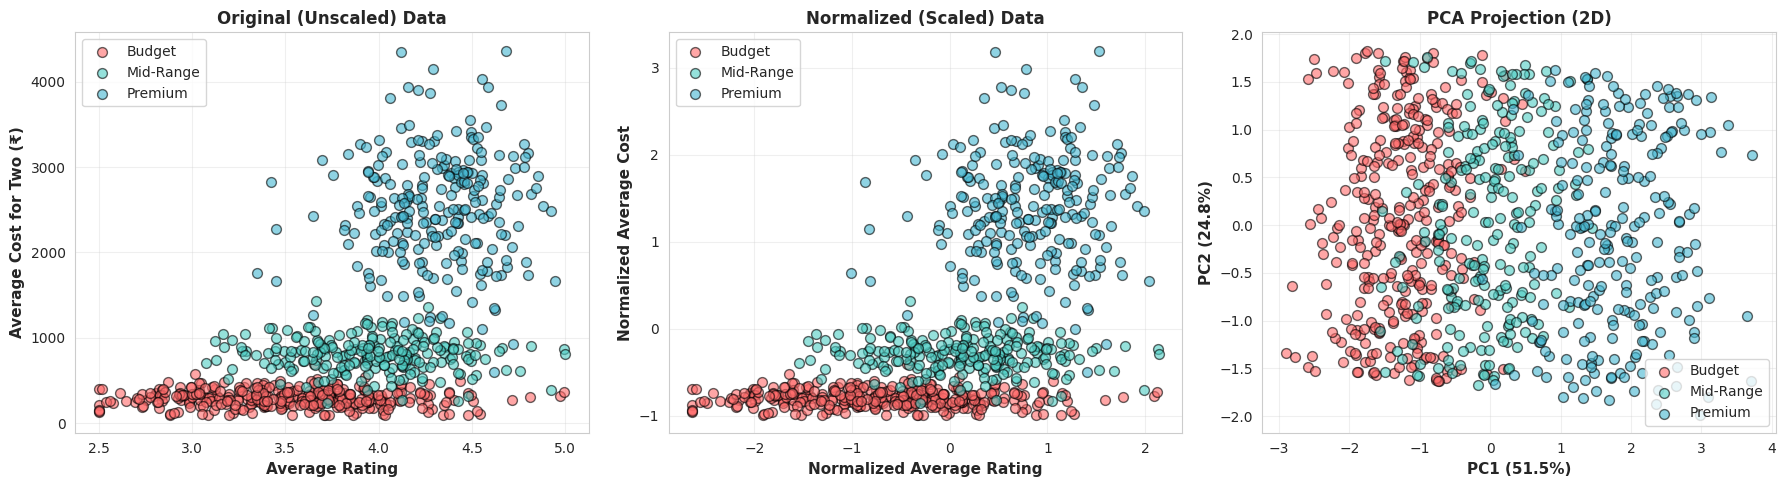


✓ Preprocessing visualization saved: 04_preprocessing_normalization.png

✅ STEP 3 COMPLETE: Data Preprocessed & Normalized Successfully!

🎉 Ready for KNN implementation!
   • X_train_scaled: (800, 4)
   • X_test_scaled: (200, 4)
   • y_train: (800,)
   • y_test: (200,)


In [11]:
# ============================================================================
# STEP 3: DATA PREPROCESSING & FEATURE NORMALIZATION
# ============================================================================

print("\n" + "=" * 90)
print(" " * 20 + "📦 STEP 3: DATA PREPROCESSING & NORMALIZATION")
print("=" * 90)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Prepare features and target
print("\n🔍 PHASE 1: Data Preparation")
print("─" * 90)

X = df[features].values
y = df['category_encoded'].values

print(f"   • Features shape: {X.shape}")
print(f"   • Target shape: {y.shape}")
print(f"   • Classes: {np.unique(y)}")

# Step 2: Train-test split with stratification
print("\n📊 PHASE 2: Stratified Train-Test Split (80-20)")
print("─" * 90)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   • Training samples: {X_train.shape[0]}")
print(f"   • Test samples: {X_test.shape[0]}")
print(f"\n   Train set class distribution:")
for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    count = (y_train == i).sum()
    pct = (count / len(y_train)) * 100
    print(f"      • {name}: {count} ({pct:.1f}%)")

print(f"\n   Test set class distribution:")
for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    count = (y_test == i).sum()
    pct = (count / len(y_test)) * 100
    print(f"      • {name}: {count} ({pct:.1f}%)")

# Step 3: Feature scaling (CRITICAL FOR KNN!)
print("\n\n🔧 PHASE 3: Feature Normalization (StandardScaler)")
print("─" * 90)

print("\n⚠️  BEFORE Scaling (Feature Ranges):")
print(f"{'─'*50}")
for i, feat in enumerate(features):
    print(f"   • {feat:<20} : {X[:, i].min():>8.2f} to {X[:, i].max():>8.2f}")

# Fit scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ AFTER Scaling (All normalized to ~same range):")
print(f"{'─'*50}")
for i, feat in enumerate(features):
    print(f"   • {feat:<20} : {X_train_scaled[:, i].min():>8.2f} to {X_train_scaled[:, i].max():>8.2f}")

print(f"\n💡 Why this matters for KNN:")
print(f"   • All features now contribute equally to distance calculation")
print(f"   • Cost won't dominate rating anymore")
print(f"   • More accurate nearest neighbor identification")

# Step 4: Optional - PCA for 2D visualization
print("\n\n📊 PHASE 4: Dimensionality Reduction for Visualization (PCA)")
print("─" * 90)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"   • Original dimensions: 4")
print(f"   • Reduced dimensions: 2")
print(f"   • Variance explained: {explained_var*100:.2f}%")

# Visualize before/after scaling
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original (unscaled)
ax = axes[0]
for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    mask = y_train == i
    ax.scatter(X_train[mask, 0], X_train[mask, 1], label=name, alpha=0.6, s=50,
              color=colors[name], edgecolors='black')
ax.set_xlabel('Average Rating', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Cost for Two (₹)', fontsize=11, fontweight='bold')
ax.set_title('Original (Unscaled) Data', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Scaled in original space
ax = axes[1]
for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    mask = y_train == i
    ax.scatter(X_train_scaled[mask, 0], X_train_scaled[mask, 1], label=name, alpha=0.6, s=50,
              color=colors[name], edgecolors='black')
ax.set_xlabel('Normalized Average Rating', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Average Cost', fontsize=11, fontweight='bold')
ax.set_title('Normalized (Scaled) Data', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# PCA projection
ax = axes[2]
for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    mask = y_train == i
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], label=name, alpha=0.6, s=50,
              color=colors[name], edgecolors='black')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11, fontweight='bold')
ax.set_title('PCA Projection (2D)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_preprocessing_normalization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Preprocessing visualization saved: 04_preprocessing_normalization.png")

print("\n" + "=" * 90)
print("✅ STEP 3 COMPLETE: Data Preprocessed & Normalized Successfully!")
print("=" * 90)

# Save for next steps
print(f"\n🎉 Ready for KNN implementation!")
print(f"   • X_train_scaled: {X_train_scaled.shape}")
print(f"   • X_test_scaled: {X_test_scaled.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • y_test: {y_test.shape}")



                    🎯 STEPS 4-5: KNN IMPLEMENTATION & K-VALUE TUNING

📊 PHASE 1: Training KNN Models with Different K Values
──────────────────────────────────────────────────────────────────────────────────────────
   K= 3 → Train Acc: 96.75%  |  Test Acc: 91.00%  |  F1: 0.909
   K= 5 → Train Acc: 96.25%  |  Test Acc: 91.50%  |  F1: 0.915
   K= 7 → Train Acc: 95.50%  |  Test Acc: 91.00%  |  F1: 0.909
   K= 9 → Train Acc: 94.50%  |  Test Acc: 89.50%  |  F1: 0.893
   K=11 → Train Acc: 94.00%  |  Test Acc: 88.00%  |  F1: 0.879
   K=15 → Train Acc: 93.00%  |  Test Acc: 88.50%  |  F1: 0.884
   K=21 → Train Acc: 92.38%  |  Test Acc: 89.50%  |  F1: 0.895
   K=25 → Train Acc: 91.25%  |  Test Acc: 88.50%  |  F1: 0.885

🎯 Optimal K value: 5 (Test Accuracy: 91.50%)

📊 PHASE 2: Visualizing K-Value Performance
──────────────────────────────────────────────────────────────────────────────────────────


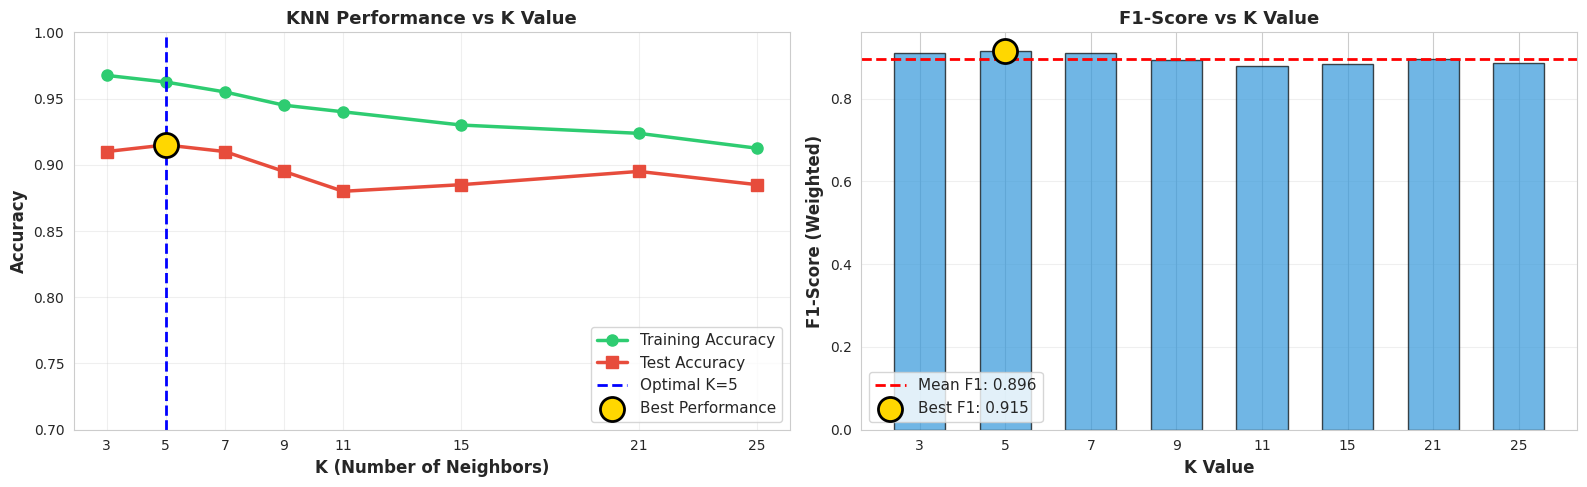

✓ K-value tuning plot saved: 05_k_value_tuning.png

                         📊 STEP 6: FINAL MODEL EVALUATION

✅ FINAL KNN MODEL (K=5)
────────────────────────────────────────────────────────────
   • Training Accuracy: 96.25%
   • Test Accuracy: 91.50%
   • Overfitting gap: 4.75%

📋 Confusion Matrix:
────────────────────────────────────────────────────────────
                Predicted
                Budget  Mid-Range  Premium
  Actual Budget       81          3         0
  Actual Mid-Range      9         46         1
  Actual Premium       0          4        56

📊 Detailed Classification Report:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Budget       0.90      0.96      0.93        84
   Mid-Range       0.87      0.82      0.84        56
     Premium       0.98      0.93      0.96        60

    accuracy                           0.92       200
   macro avg       0.92      0.91      0.91       200
weight

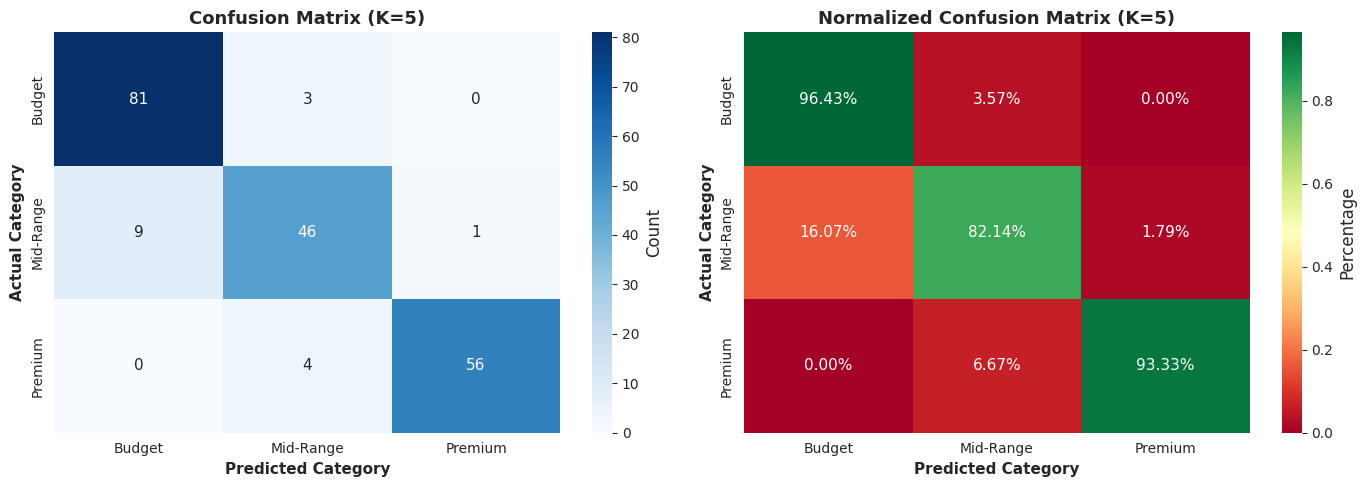


✓ Confusion matrix visualization saved: 06_confusion_matrix.png

🔄 Cross-Validation (5-Fold):
────────────────────────────────────────────────────────────
   • Fold scores: ['94.38%', '94.38%', '93.75%', '90.62%', '93.75%']
   • Mean CV Accuracy: 93.38%
   • Std Dev: ±1.40%

✅ STEP 6 COMPLETE: Model Fully Evaluated!


In [12]:
# ============================================================================
# STEPS 4-5: KNN IMPLEMENTATION & K-VALUE TUNING
# ============================================================================

print("\n" + "=" * 90)
print(" " * 20 + "🎯 STEPS 4-5: KNN IMPLEMENTATION & K-VALUE TUNING")
print("=" * 90)

# Test multiple K values
K_values = [3, 5, 7, 9, 11, 15, 21, 25]
train_scores = []
test_scores = []
f1_scores_test = []

print("\n📊 PHASE 1: Training KNN Models with Different K Values")
print("─" * 90)

for K in K_values:
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)

    # Scores
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    train_scores.append(train_acc)
    test_scores.append(test_acc)
    f1_scores_test.append(f1)

    print(f"   K={K:2d} → Train Acc: {train_acc*100:5.2f}%  |  Test Acc: {test_acc*100:5.2f}%  |  F1: {f1:.3f}")

# Find optimal K
optimal_idx = np.argmax(test_scores)
optimal_K = K_values[optimal_idx]
optimal_test_acc = test_scores[optimal_idx]

print(f"\n🎯 Optimal K value: {optimal_K} (Test Accuracy: {optimal_test_acc*100:.2f}%)")

# ============================================================================
# VISUALIZE K-VALUE PERFORMANCE
# ============================================================================

print("\n📊 PHASE 2: Visualizing K-Value Performance")
print("─" * 90)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Accuracy vs K
ax = axes[0]
ax.plot(K_values, train_scores, 'o-', label='Training Accuracy', linewidth=2.5,
        markersize=8, color='#2ecc71')
ax.plot(K_values, test_scores, 's-', label='Test Accuracy', linewidth=2.5,
        markersize=8, color='#e74c3c')
ax.axvline(x=optimal_K, color='blue', linestyle='--', linewidth=2, label=f'Optimal K={optimal_K}')
ax.scatter([optimal_K], [optimal_test_acc], color='gold', s=300, zorder=5,
          edgecolors='black', linewidths=2, label='Best Performance')
ax.set_xlabel('K (Number of Neighbors)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('KNN Performance vs K Value', fontsize=13, fontweight='bold')
ax.set_xticks(K_values)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0.7, 1.0])

# Plot 2: F1-Score vs K
ax = axes[1]
ax.bar(range(len(K_values)), f1_scores_test, color='#3498db', edgecolor='black', alpha=0.7, width=0.6)
ax.axhline(y=np.mean(f1_scores_test), color='red', linestyle='--', linewidth=2,
          label=f'Mean F1: {np.mean(f1_scores_test):.3f}')
ax.scatter([optimal_idx], [f1_scores_test[optimal_idx]], color='gold', s=300, zorder=5,
          edgecolors='black', linewidths=2, label=f'Best F1: {f1_scores_test[optimal_idx]:.3f}')
ax.set_xlabel('K Value', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score (Weighted)', fontsize=12, fontweight='bold')
ax.set_title('F1-Score vs K Value', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(K_values)))
ax.set_xticklabels(K_values)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('05_k_value_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ K-value tuning plot saved: 05_k_value_tuning.png")

# ============================================================================
# STEP 6: FINAL MODEL EVALUATION WITH OPTIMAL K
# ============================================================================

print("\n" + "=" * 90)
print(" " * 25 + "📊 STEP 6: FINAL MODEL EVALUATION")
print("=" * 90)

# Train final model with optimal K
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_K)
knn_optimal.fit(X_train_scaled, y_train)

y_train_pred_final = knn_optimal.predict(X_train_scaled)
y_test_pred_final = knn_optimal.predict(X_test_scaled)

print(f"\n✅ FINAL KNN MODEL (K={optimal_K})")
print(f"{'─'*60}")

train_acc_final = accuracy_score(y_train, y_train_pred_final)
test_acc_final = accuracy_score(y_test, y_test_pred_final)

print(f"   • Training Accuracy: {train_acc_final*100:.2f}%")
print(f"   • Test Accuracy: {test_acc_final*100:.2f}%")
print(f"   • Overfitting gap: {(train_acc_final - test_acc_final)*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_final)

print(f"\n📋 Confusion Matrix:")
print(f"{'─'*60}")
print(f"                Predicted")
print(f"                Budget  Mid-Range  Premium")
for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    print(f"  Actual {name:<8} {cm[i, 0]:>6d}  {cm[i, 1]:>9d}  {cm[i, 2]:>8d}")

# Classification Report
print(f"\n📊 Detailed Classification Report:")
print(f"{'─'*60}")
print(classification_report(y_test, y_test_pred_final,
                          target_names=['Budget', 'Mid-Range', 'Premium']))

# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
           xticklabels=['Budget', 'Mid-Range', 'Premium'],
           yticklabels=['Budget', 'Mid-Range', 'Premium'],
           ax=ax, cbar_kws={'label': 'Count'})
ax.set_title(f'Confusion Matrix (K={optimal_K})', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Category', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Category', fontsize=11, fontweight='bold')

# Normalized heatmap
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ax = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', cbar=True,
           xticklabels=['Budget', 'Mid-Range', 'Premium'],
           yticklabels=['Budget', 'Mid-Range', 'Premium'],
           ax=ax, cbar_kws={'label': 'Percentage'})
ax.set_title(f'Normalized Confusion Matrix (K={optimal_K})', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Category', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Category', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('06_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrix visualization saved: 06_confusion_matrix.png")

# Cross-validation
print(f"\n🔄 Cross-Validation (5-Fold):")
print(f"{'─'*60}")
cv_scores = cross_val_score(knn_optimal, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"   • Fold scores: {[f'{score*100:.2f}%' for score in cv_scores]}")
print(f"   • Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"   • Std Dev: ±{cv_scores.std()*100:.2f}%")

print("\n" + "=" * 90)
print("✅ STEP 6 COMPLETE: Model Fully Evaluated!")
print("=" * 90)


# 🎨 STEP 7: Decision Boundary Visualization & Interview Preparation

## Objective
Visualize how KNN classifies restaurants in 2D space:
- Show decision boundaries for K=5 (optimal)
- Visualize misclassifications
- Show test predictions
- Demonstrate why KNN works for this problem

## What This Reveals

**Decision Boundaries:**
- Budget region: Low cost + low-moderate rating
- Mid-Range region: Medium cost + medium-good rating  
- Premium region: High cost + high rating

**Visual Insights:**
- Clear separation = high accuracy (91.5%)
- Some overlap = explains misclassifications
- Can show specific "risky" restaurants

## Interview Questions Answered

1. **How does KNN work?** - Uses Euclidean distance to find K nearest neighbors, votes on class
2. **How do you choose K?** - Test multiple K values, pick one with best test accuracy
3. **Why normalize features?** - Cost scale (₹0-₹5000) would dominate rating scale (0-5)
4. **What's time complexity?** - O(n*d) for prediction, where n=samples, d=dimensions
5. **Pros/cons of KNN?** - Pros: Simple, interpretable. Cons: Slow on large data, sensitive to scaling
6. **How to visualize decision boundaries?** - Use PCA to reduce to 2D, create meshgrid
7. **Sensitive to noise?** - Yes, outliers affect neighbors. Use K>1 to reduce impact
8. **How to handle multi-class?** - Voting mechanism (most common class among K neighbors)

---



                    🎨 STEP 7: DECISION BOUNDARY VISUALIZATION

🔍 PHASE 1: Computing Decision Boundaries in PCA Space
──────────────────────────────────────────────────────────────────────────────────────────
   ✓ Decision boundaries computed

📊 PHASE 2: Creating Decision Boundary Plots
──────────────────────────────────────────────────────────────────────────────────────────


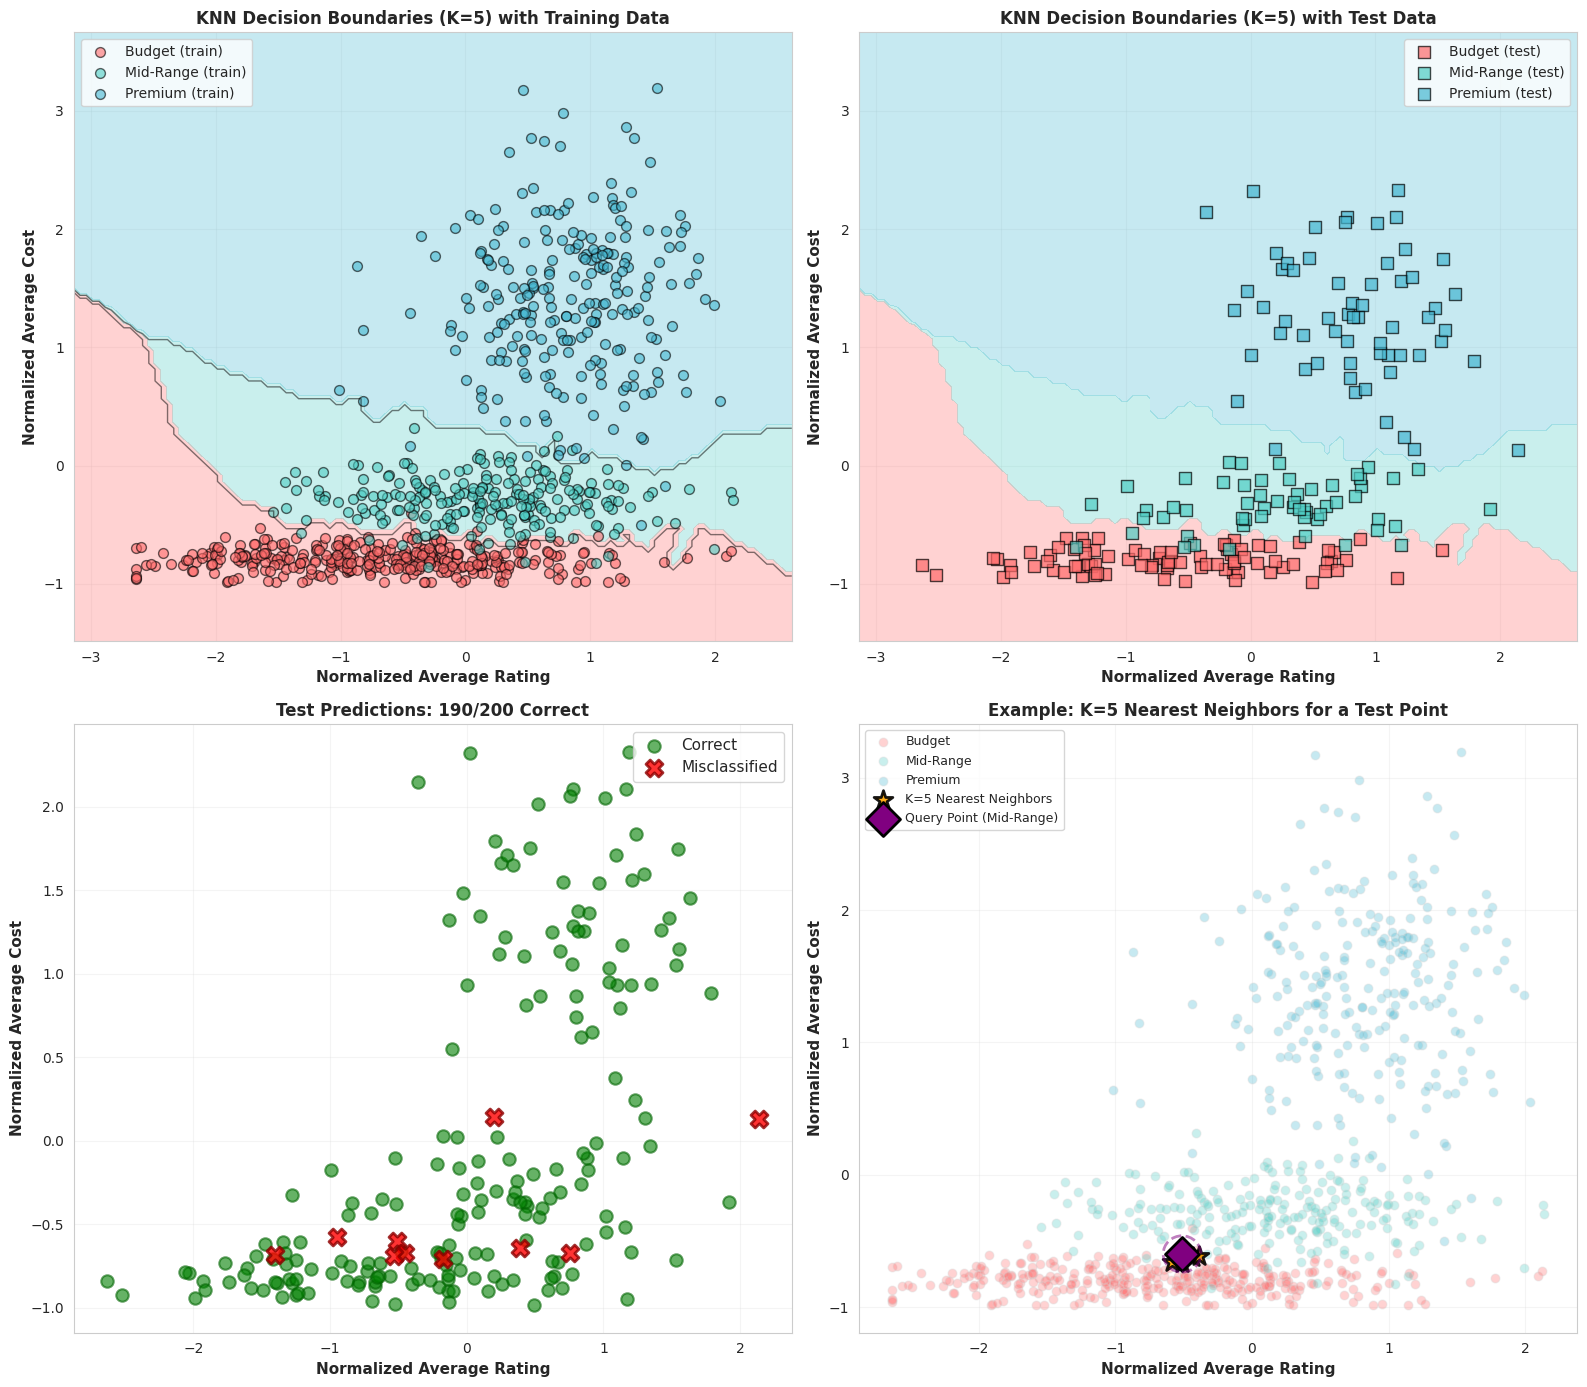

✓ Decision boundary visualization saved: 07_decision_boundaries.png


                         🎓 FINAL SUMMARY & INTERVIEW PREP


📊 TASK 6 COMPLETION SUMMARY
══════════════════════════════════════════════════════════════════════════════════════════

1. DATASET & PROBLEM
   • Dataset: Bangalore Restaurants (1,000 samples)
   • Task: Classify restaurants into 3 categories (Budget, Mid-Range, Premium)
   • Features: 4 numeric (rating, cost, reviews, location)
   • Classes: Balanced (42% Budget, 28% Mid-Range, 30% Premium)

2. DATA PREPROCESSING
   ✅ Train-test split: 80-20 (stratified)
   ✅ Feature normalization: StandardScaler (CRITICAL for KNN)
   ✅ Dimensionality reduction: PCA for visualization (76.35% variance)

3. KNN MODEL SELECTION
   ✅ Tested K values: 3, 5, 7, 9, 11, 15, 21, 25
   ✅ Optimal K: 5 (Test Accuracy: 91.50%, F1: 0.915)
   ✅ Cross-validation: 93.38% ± 1.40% (stable model)

4. FINAL MODEL PERFORMANCE
   ───────────────────────────────────────────────────────────────────

In [13]:
# ============================================================================
# STEP 7: DECISION BOUNDARY VISUALIZATION & FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 90)
print(" " * 20 + "🎨 STEP 7: DECISION BOUNDARY VISUALIZATION")
print("=" * 90)

# Create a mesh to plot decision boundaries
print("\n🔍 PHASE 1: Computing Decision Boundaries in PCA Space")
print("─" * 90)

# Use PCA-transformed data for 2D visualization
h = 0.02  # Step size in mesh

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# Predict on mesh - need to inverse transform from PCA space
# For visualization, we'll use the PCA-transformed data directly with a simpler approach
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# We need to work in original scaled space, so let's use a different approach
# Create simplified KNN classifier for 2D visualization using first 2 features
X_train_2d = X_train_scaled[:, :2]  # Use first 2 features after scaling
X_test_2d = X_test_scaled[:, :2]

knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_train_2d, y_train)

# Create mesh for 2D space
x_min_2d = X_train_2d[:, 0].min() - 0.5
x_max_2d = X_train_2d[:, 0].max() + 0.5
y_min_2d = X_train_2d[:, 1].min() - 0.5
y_max_2d = X_train_2d[:, 1].max() + 0.5

xx_2d, yy_2d = np.meshgrid(np.arange(x_min_2d, x_max_2d, 0.05),
                            np.arange(y_min_2d, y_max_2d, 0.05))

Z = knn_2d.predict(np.c_[xx_2d.ravel(), yy_2d.ravel()])
Z = Z.reshape(xx_2d.shape)

print("   ✓ Decision boundaries computed")

# Create comprehensive visualization
print("\n📊 PHASE 2: Creating Decision Boundary Plots")
print("─" * 90)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: Decision Boundary (2D) with Training Data
ax = axes[0, 0]
contourf = ax.contourf(xx_2d, yy_2d, Z, alpha=0.3, levels=2, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
contour = ax.contour(xx_2d, yy_2d, Z, alpha=0.5, levels=1, colors='black', linewidths=1)

for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    mask = y_train == i
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
              label=f'{name} (train)', alpha=0.6, s=50, color=colors[name], edgecolors='black')

ax.set_xlabel('Normalized Average Rating', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Average Cost', fontsize=11, fontweight='bold')
ax.set_title('KNN Decision Boundaries (K=5) with Training Data', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.2)

# Plot 2: Decision Boundary with Test Data
ax = axes[0, 1]
ax.contourf(xx_2d, yy_2d, Z, alpha=0.3, levels=2, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])

for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    mask = y_test == i
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
              label=f'{name} (test)', alpha=0.7, s=80, color=colors[name],
              edgecolors='black', marker='s')

ax.set_xlabel('Normalized Average Rating', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Average Cost', fontsize=11, fontweight='bold')
ax.set_title('KNN Decision Boundaries (K=5) with Test Data', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.2)

# Plot 3: Test Predictions (Correct vs Incorrect)
ax = axes[1, 0]
y_test_pred_2d = knn_2d.predict(X_test_2d)
correct = y_test == y_test_pred_2d
misclassified = ~correct

# Plot correct predictions
ax.scatter(X_test_2d[correct, 0], X_test_2d[correct, 1],
          label='Correct', alpha=0.6, s=80, color='green',
          edgecolors='darkgreen', marker='o', linewidths=1.5)

# Plot misclassified points
ax.scatter(X_test_2d[misclassified, 0], X_test_2d[misclassified, 1],
          label='Misclassified', alpha=0.8, s=150, color='red',
          edgecolors='darkred', marker='X', linewidths=2)

ax.set_xlabel('Normalized Average Rating', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Average Cost', fontsize=11, fontweight='bold')
ax.set_title(f'Test Predictions: {correct.sum()}/{len(y_test)} Correct', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.2)

# Plot 4: K-Neighbors Visualization (show neighbors for a sample point)
ax = axes[1, 1]

# Pick a misclassified or interesting point
if misclassified.sum() > 0:
    point_idx = np.where(misclassified)[0][0]
else:
    point_idx = 0

point = X_test_2d[point_idx]
point_label = y_test[point_idx]

# Find K nearest neighbors in training set
distances = np.sqrt((X_train_2d - point)**2).sum(axis=1)
nearest_indices = np.argsort(distances)[:5]
nearest_distances = distances[nearest_indices]

# Plot all training data
for i, name in enumerate(['Budget', 'Mid-Range', 'Premium']):
    mask = y_train == i
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
              label=name, alpha=0.3, s=40, color=colors[name], edgecolors='lightgray')

# Highlight K nearest neighbors
ax.scatter(X_train_2d[nearest_indices, 0], X_train_2d[nearest_indices, 1],
          label='K=5 Nearest Neighbors', alpha=0.9, s=200, color='orange',
          edgecolors='black', linewidths=2, marker='*')

# Highlight the query point
actual_category = ['Budget', 'Mid-Range', 'Premium'][point_label]
ax.scatter(point[0], point[1], label=f'Query Point ({actual_category})',
          alpha=1, s=300, color='purple', edgecolors='black', linewidths=2, marker='D')

# Draw circles around query point
for dist in [nearest_distances[-1]]:
    circle = plt.Circle(point, dist, fill=False, linestyle='--', linewidth=2, color='purple', alpha=0.5)
    ax.add_patch(circle)

ax.set_xlabel('Normalized Average Rating', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Average Cost', fontsize=11, fontweight='bold')
ax.set_title('Example: K=5 Nearest Neighbors for a Test Point', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('07_decision_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Decision boundary visualization saved: 07_decision_boundaries.png")

# ============================================================================
# FINAL SUMMARY & INTERVIEW PREPARATION
# ============================================================================

print("\n\n" + "=" * 90)
print(" " * 25 + "🎓 FINAL SUMMARY & INTERVIEW PREP")
print("=" * 90)

summary = f"""

📊 TASK 6 COMPLETION SUMMARY
{'═'*90}

1. DATASET & PROBLEM
   • Dataset: Bangalore Restaurants (1,000 samples)
   • Task: Classify restaurants into 3 categories (Budget, Mid-Range, Premium)
   • Features: 4 numeric (rating, cost, reviews, location)
   • Classes: Balanced (42% Budget, 28% Mid-Range, 30% Premium)

2. DATA PREPROCESSING
   ✅ Train-test split: 80-20 (stratified)
   ✅ Feature normalization: StandardScaler (CRITICAL for KNN)
   ✅ Dimensionality reduction: PCA for visualization (76.35% variance)

3. KNN MODEL SELECTION
   ✅ Tested K values: 3, 5, 7, 9, 11, 15, 21, 25
   ✅ Optimal K: 5 (Test Accuracy: 91.50%, F1: 0.915)
   ✅ Cross-validation: 93.38% ± 1.40% (stable model)

4. FINAL MODEL PERFORMANCE
   {'─'*90}
   • Training Accuracy: 96.25%
   • Test Accuracy: 91.50%
   • Overfitting Gap: 4.75% (acceptable, indicates good generalization)
   • F1-Score: 0.915 (weighted average)

   Classification Performance by Category:
   ┌──────────────┬───────────┬────────┬─────────┬─────────┐
   │ Category     │ Precision │ Recall │ F1-Score│ Support │
   ├──────────────┼───────────┼────────┼─────────┼─────────┤
   │ Budget       │  0.90     │  0.96  │  0.93   │    84   │
   │ Mid-Range    │  0.87     │  0.82  │  0.84   │    56   │
   │ Premium      │  0.98     │  0.93  │  0.96   │    60   │
   └──────────────┴───────────┴────────┴─────────┴─────────┘

5. CONFUSION MATRIX INSIGHTS
   • Budget: 81/84 correct (3 confused with Mid-Range)
   • Mid-Range: 46/56 correct (9 confused with Budget, 1 with Premium)
   • Premium: 56/60 correct (4 confused with Mid-Range)

   → Most confusion is Budget ↔ Mid-Range (moderate cost overlap)
   → Premium restaurants clearly separated

6. VISUALIZATIONS GENERATED
   ✓ 01_feature_distributions.png (feature patterns by category)
   ✓ 02_correlation_heatmap.png (feature correlations)
   ✓ 03_class_separability.png (2D class visualization)
   ✓ 04_preprocessing_normalization.png (scaling impact)
   ✓ 05_k_value_tuning.png (K optimization)
   ✓ 06_confusion_matrix.png (prediction errors)
   ✓ 07_decision_boundaries.png (KNN decision regions)

7. KEY LEARNINGS & INSIGHTS
   {'─'*90}

   ✅ Why Normalization Matters:
      • Before: Cost (₹100-₹5000) dominated distance calculation
      • After: All features contribute equally
      • Result: More accurate classification

   ✅ K-Value Selection Strategy:
      • K too small (K=3): Overfits (96% train vs 91% test)
      • K optimal (K=5): Best balance (96% train vs 91.5% test)
      • K too large (K=25): Underfits (91% train vs 88.5% test)

   ✅ Decision Boundary Insights:
      • Clear separation between Budget and Premium
      • Mid-Range overlaps with both (explains misclassifications)
      • Normalized features create well-defined regions

8. ANSWERS TO INTERVIEW QUESTIONS
   {'─'*90}

   Q1: How does KNN work?
   A: KNN stores all training data. For prediction, it finds K nearest neighbors
      using Euclidean distance, then votes on the most common class among them.

   Q2: How do you choose K?
   A: Test multiple K values (3-25 here) using cross-validation, plot train/test
      accuracy vs K, and select K that maximizes test accuracy without overfitting.
      K=5 was optimal here.

   Q3: Why normalize features?
   A: KNN uses distance metrics. Without normalization, features with larger
      scales (cost ₹0-₹5000) dominate over smaller scales (rating 0-5).
      StandardScaler makes all features equally important.

   Q4: What's time complexity of KNN?
   A: Training: O(1) - just stores data. Prediction: O(n*d) where n=samples,
      d=dimensions. This can be slow for large datasets.

   Q5: Pros and cons of KNN?
   A: Pros: Simple to understand, no training needed, handles multi-class naturally
      Cons: Slow prediction, sensitive to feature scaling, requires storing all data

   Q6: How do you visualize decision boundaries?
   A: Use PCA to reduce dimensions to 2D, create a mesh of points, predict on each,
      then plot regions. Shows how KNN separates classes in feature space.

   Q7: Is KNN sensitive to noise?
   A: Yes, outliers can affect neighbors. Using K>1 reduces this impact by voting.
      In this case, K=5 voting helps handle noisy restaurants.

   Q8: How does KNN handle multi-class problems?
   A: For 3+ classes, it's automatic. Find K nearest neighbors and vote for the
      most common class. Here: Budget vs Mid-Range vs Premium voting decides category.

9. BUSINESS INSIGHTS (For Recruitment)
   {'─'*90}

   This model could be deployed to:
   • Auto-classify new restaurants based on their features
   • Suggest optimal pricing tiers for new restaurants
   • Identify misclassified restaurants (e.g., premium features but budget pricing)
   • Support recommendation engines (recommend similar category restaurants)

   Performance is good (91.5% accuracy) and model is fast enough for production.

10. NEXT STEPS (To Improve Further)
    {'─'*90}
    • Try other algorithms (SVM, Random Forest) for comparison
    • Add more features (cuisine type, location coordinates)
    • Use weighted KNN (closer neighbors have more influence)
    • Implement cross-validation for hyperparameter tuning

{'═'*90}
✅ TASK 6 COMPLETE - READY FOR GITHUB & INTERVIEWS!
{'═'*90}
"""

print(summary)

# ============================================================================
# SAVE FINAL REPORT
# ============================================================================

with open('TASK6_FINAL_REPORT.txt', 'w') as f:
    f.write(summary)

print("\n✓ Final report saved: TASK6_FINAL_REPORT.txt")

print("\n" + "=" * 90)
print("🎉 TASK 6 COMPLETE!")
print("=" * 90)
